# Loan Approval Prediction using Machine Learning

## Project Overview

This project aims to analyze factors influencing loan approval and build machine learning models to predict whether a loan application will be approved. The workflow includes data cleaning, exploratory data analysis (EDA), feature engineering, model building, and performance evaluation.

### Objectives

- Understand the dataset through exploratory analysis.
- Clean and preprocess the data.
- Visualize relationships between applicant features and loan approval.
- Build multiple machine learning models.
- Compare model performance and identify the best-performing model.

## Step 1: Import Required Libraries

Import the necessary libraries for data manipulation, visualization, machine learning, and model evaluation.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Step 2: Load the Dataset

Load the loan approval dataset into a Pandas DataFrame and display the first few records to understand its structure.

In [3]:
# Load the dataset
df = pd.read_csv("loan_prediction.csv")

# Display the first five rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Step 3: Explore the Dataset

Before cleaning or building models, it is important to understand the dataset's structure. This includes checking the number of rows and columns, data types, missing values, duplicate records, and summary statistics.

In [4]:
# Display the number of rows and columns
df.shape

(614, 13)

In [5]:
# Display all column names
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [6]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [7]:
# Summary statistics for numerical columns
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
# Check for missing values
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

## Step 4: Data Cleaning

The dataset contains missing values in both categorical and numerical columns. Before performing analysis or training machine learning models, these missing values must be handled appropriately.

In this step, we will:
- Remove unnecessary columns.
- Fill missing values in categorical columns using the mode (most frequent value).
- Fill missing values in numerical columns using the median.
- Verify that the dataset no longer contains missing values.

In [10]:
# Remove Loan_ID as it does not contribute to prediction
df.drop("Loan_ID", axis=1, inplace=True)

# Display remaining columns
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [13]:
# Fill missing values in categorical columns with mode
categorical_cols = ["Gender", "Married", "Dependents", "Self_Employed"]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill missing values in numerical columns with median
numerical_cols = ["LoanAmount", "Loan_Amount_Term", "Credit_History"]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [14]:
# Verify that all missing values have been handled
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Step 5: Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps uncover patterns, relationships, and trends within the dataset. In this section, we will visualize the distribution of variables and examine how different applicant characteristics influence loan approval.

### 5.1 Loan Approval Distribution

This visualization shows the number of approved and rejected loan applications, helping us understand whether the dataset is balanced.

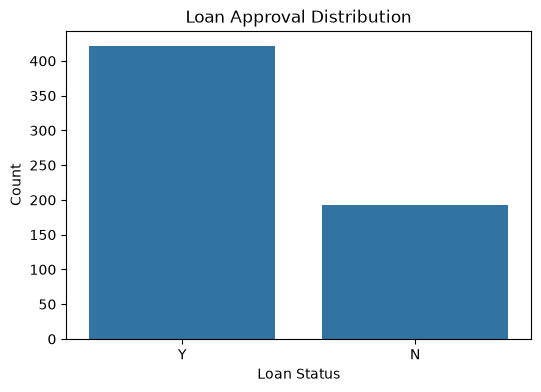

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

### 5.2 Gender Distribution

This chart displays the distribution of applicants based on gender.

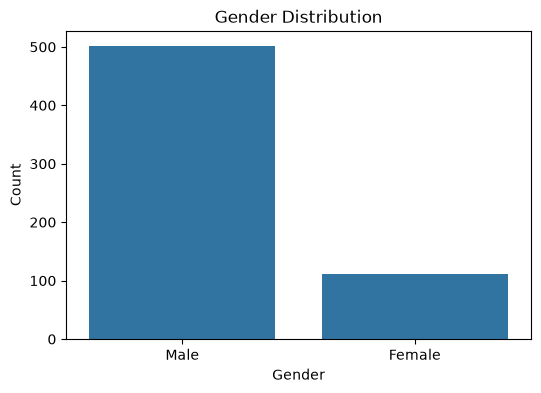

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### 5.3 Education vs Loan Approval

This visualization compares loan approval status across different education levels.

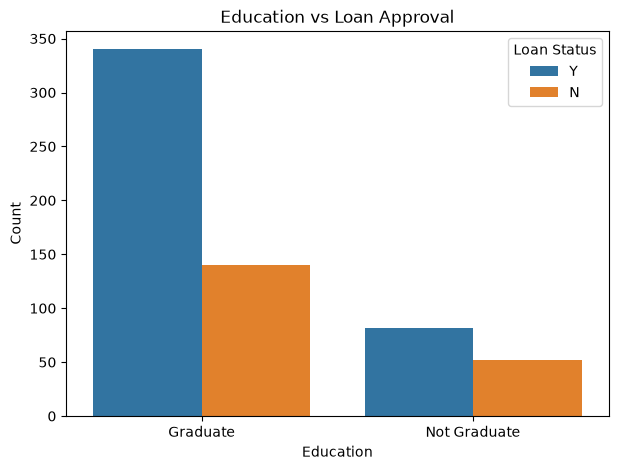

In [18]:
plt.figure(figsize=(7,5))
sns.countplot(x='Education', hue='Loan_Status', data=df)

plt.title("Education vs Loan Approval")
plt.xlabel("Education")
plt.ylabel("Count")

plt.legend(title="Loan Status")

plt.show()

### 5.4 Credit History vs Loan Approval

Credit history is one of the most important factors considered by financial institutions when approving loans. This visualization compares loan approval status based on an applicant's credit history.

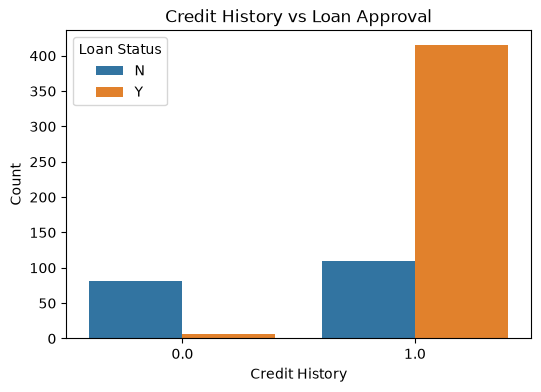

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)

plt.title("Credit History vs Loan Approval")
plt.xlabel("Credit History")
plt.ylabel("Count")

plt.legend(title="Loan Status")

plt.show()

### 5.5 Property Area vs Loan Approval

This visualization examines whether the property location influences loan approval decisions.

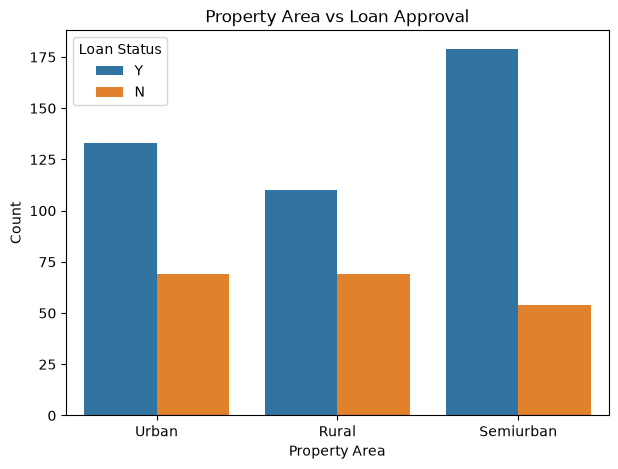

In [20]:
plt.figure(figsize=(7,5))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)

plt.title("Property Area vs Loan Approval")
plt.xlabel("Property Area")
plt.ylabel("Count")

plt.legend(title="Loan Status")

plt.show()

### 5.6 Married Status vs Loan Approval

This visualization compares loan approval based on the marital status of applicants.

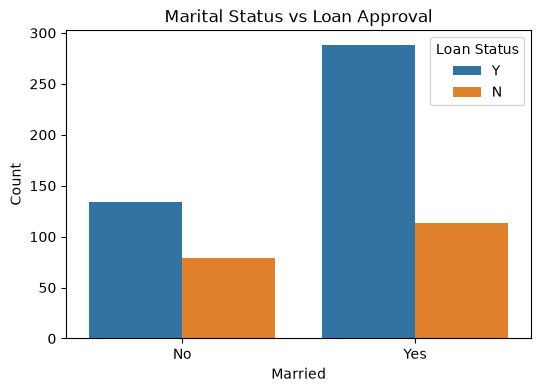

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='Married', hue='Loan_Status', data=df)

plt.title("Marital Status vs Loan Approval")
plt.xlabel("Married")
plt.ylabel("Count")

plt.legend(title="Loan Status")

plt.show()

### 5.7 Applicant Income Distribution

This histogram shows the distribution of applicants' incomes and helps identify skewness or outliers.

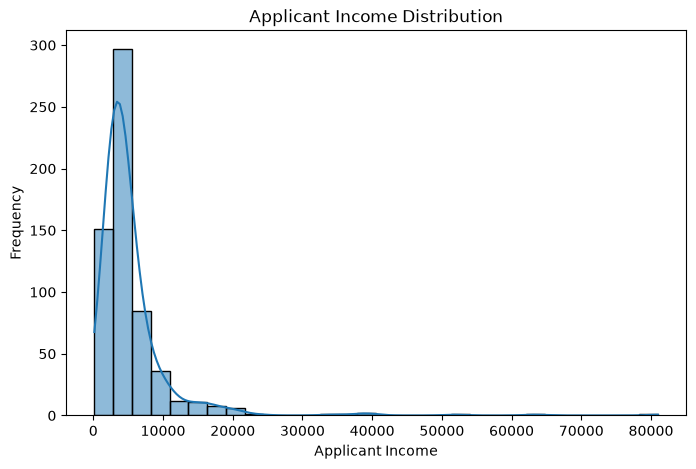

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['ApplicantIncome'], bins=30, kde=True)

plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()

### 5.8 Loan Amount Distribution

This histogram illustrates the distribution of loan amounts requested by applicants.

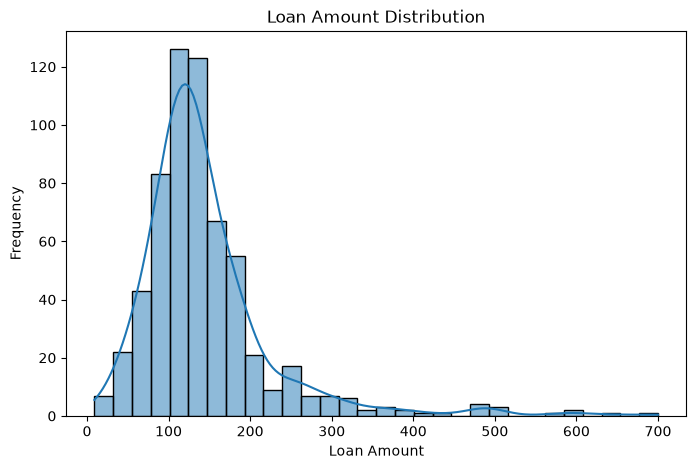

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], bins=30, kde=True)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

### 5.9 Correlation Heatmap

A correlation heatmap shows the strength of relationships between numerical variables in the dataset. Values closer to 1 or -1 indicate stronger positive or negative correlations, while values near 0 indicate weak relationships.

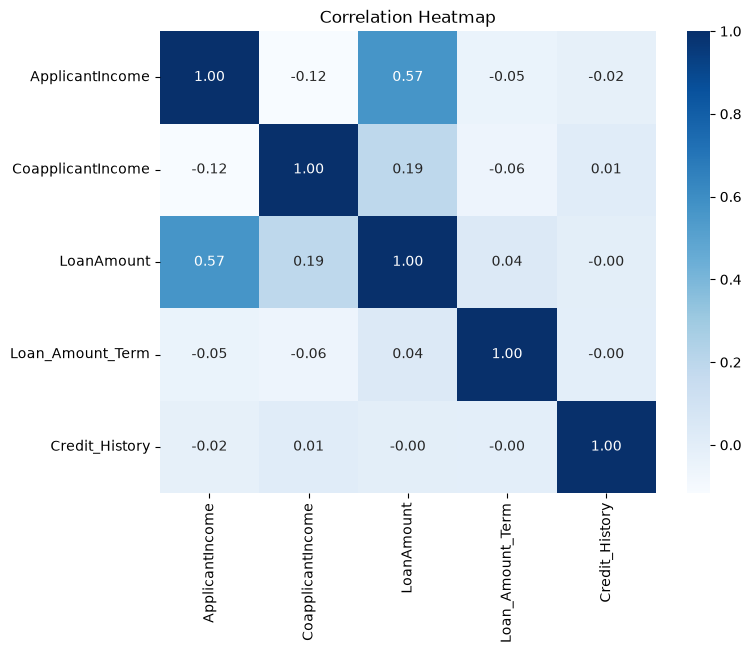

In [24]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

## Step 6: Data Preprocessing

Machine learning models require numerical input. In this step, we will:

- Convert categorical variables into numerical values.
- Separate the features and target variable.
- Split the dataset into training and testing sets.
- Standardize the numerical features to improve model performance.

In [25]:
# Create a LabelEncoder object
le = LabelEncoder()

# Encode categorical columns
categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Display first five rows
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [26]:
# Features
X = df.drop("Loan_Status", axis=1)

# Target
y = df["Loan_Status"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (614, 11)
Target Shape: (614,)


In [27]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (491, 11)
Testing Data: (123, 11)


In [28]:
# Initialize StandardScaler
scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 7: Model Building

In this step, we will train multiple machine learning models to predict loan approval. The performance of each model will be evaluated and compared to determine the most suitable model for this dataset.

### 7.1 Logistic Regression

Logistic Regression is a widely used classification algorithm that predicts the probability of an applicant receiving loan approval.

In [30]:
# Train Logistic Regression model
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7886178861788617


### 7.2 Decision Tree Classifier

Decision Trees classify data by learning a series of decision rules from the training data. They are easy to interpret and handle both numerical and categorical features.

In [31]:
# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.6910569105691057


### 7.3 Random Forest Classifier

Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [32]:
# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7560975609756098


## Step 8: Model Comparison

The accuracy of all three machine learning models is compared to identify which model performs best on the testing dataset.

In [33]:
# Create a comparison DataFrame
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.788618
1,Decision Tree,0.691057
2,Random Forest,0.756098


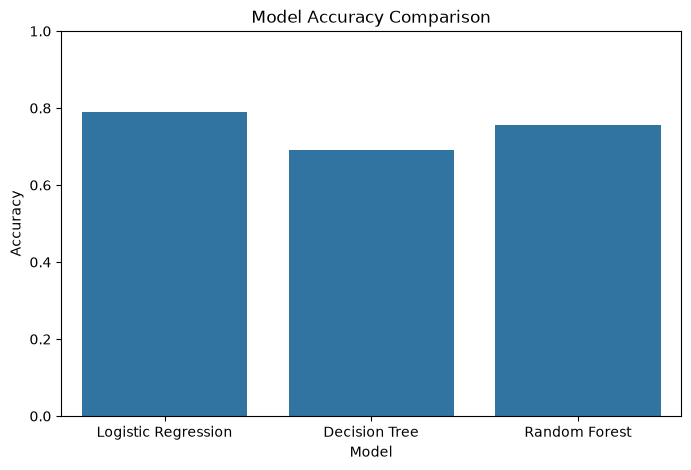

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=model_comparison
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

## Step 9: Model Evaluation

After training the machine learning models, the best-performing model (Logistic Regression) is evaluated using a confusion matrix and classification report to assess its prediction performance.

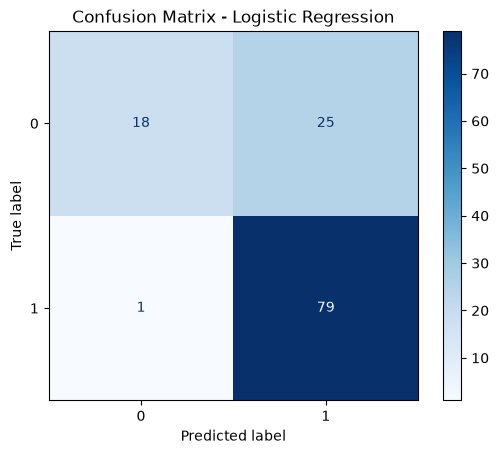

In [35]:
# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)

# Display Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [36]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



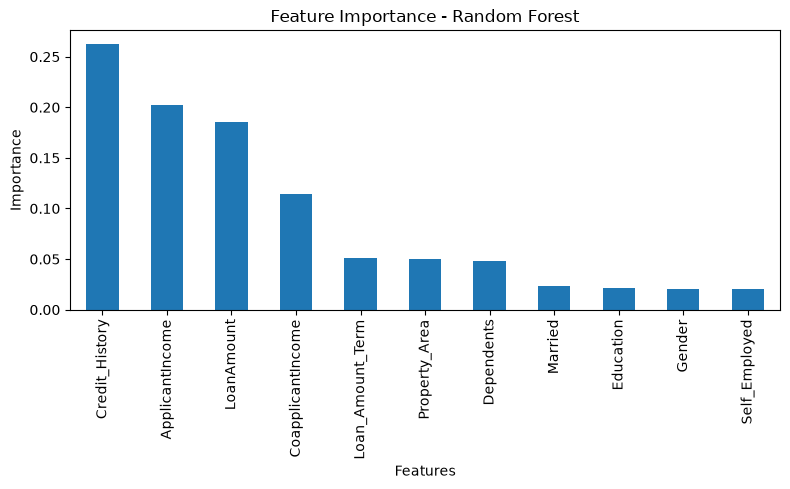

In [37]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.plot(kind='bar')

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

## Step 10: Conclusion

This project analyzed various factors affecting loan approval and developed multiple machine learning models to predict loan approval status.

Key findings include:

- The dataset contained missing values, which were handled using appropriate imputation techniques.
- Exploratory Data Analysis revealed that applicants with a good credit history had significantly higher loan approval rates.
- Logistic Regression achieved the highest prediction accuracy among the evaluated models.
- The model can assist financial institutions in making data-driven loan approval decisions while reducing manual effort.

Future improvements may include hyperparameter tuning, feature engineering, and testing additional machine learning algorithms such as XGBoost or LightGBM to further improve prediction performance.